<a href="https://colab.research.google.com/github/sanjay-sj87/computer_vision/blob/main/MNIST_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
import torch
from torchvision import datasets, transforms

In [127]:
dataset = datasets.MNIST(root='./data', train=True, download=True,
                         transform=transforms.ToTensor())

In [128]:
x_train = dataset.data
y_train = dataset.targets

In [129]:
selected_classes = [0, 1, 2]

In [130]:
for cls in selected_classes:
    indices = (y_train == cls).nonzero(as_tuple=True)[0][:100]
    print(indices)

tensor([   1,   21,   34,   37,   51,   56,   63,   68,   69,   75,   81,   88,
          95,  108,  114,  118,  119,  121,  156,  169,  192,  206,  209,  210,
         216,  229,  232,  234,  246,  249,  260,  283,  293,  296,  303,  320,
         326,  359,  399,  427,  429,  435,  440,  451,  453,  458,  462,  464,
         473,  489,  519,  524,  526,  527,  542,  577,  582,  596,  603,  612,
         633,  639,  656,  662,  666,  667,  668,  669,  689,  702,  709,  712,
         733,  743,  745,  776,  781,  787,  790,  818,  825,  849,  859,  860,
         869,  872,  889,  903,  927,  943,  949,  952,  957,  965,  979,  984,
         997, 1000, 1015, 1018])
tensor([  3,   6,   8,  14,  23,  24,  40,  59,  67,  70,  72,  77,  78,  99,
        102, 104, 105, 112, 113, 124, 128, 134, 152, 174, 177, 184, 200, 201,
        205, 208, 211, 224, 231, 248, 251, 269, 270, 276, 290, 309, 310, 315,
        345, 351, 355, 357, 358, 366, 382, 394, 397, 398, 406, 408, 416, 443,
        447, 45

In [131]:
x_final, y_final = [], []
for cls in selected_classes:
    indices = (y_train == cls).nonzero(as_tuple=True)[0][:100]
    x_final.append(x_train[indices])
    y_final.append(y_train[indices])

In [132]:
len(x_final)

3

In [133]:
xx = torch.cat(x_final)
yy = torch.cat(y_final)

In [134]:
yy

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [135]:
from torch.utils.data import TensorDataset, DataLoader

In [136]:
dataset = TensorDataset(xx, yy)

In [137]:
data = DataLoader(dataset, batch_size=32, shuffle=True)

In [138]:
for batch in data:
    print(batch[0].shape)
    break

torch.Size([32, 28, 28])


In [139]:
import zipfile
import os

In [140]:
import zipfile
import os
import shutil # Import shutil for rmtree

# Get the name of the uploaded zip file dynamically
if uploaded:
    zip_file_path = list(uploaded.keys())[0]
else:
    print("Error: No file was uploaded. Please upload a zip file.")
    zip_file_path = None # Set to None to prevent further execution if no file

extract_dir = '.' # Extract to the current directory

if zip_file_path:
    # --- Start: Robust Cleanup (adjusted for user uploaded file) ---
    print(f"Ensuring clean slate before extraction of '{zip_file_path}'.")
    # Remove existing extracted 'Images' directory if it exists
    # This assumes the uploaded zip extracts into a directory named 'Images'
    if os.path.exists('Images'):
        shutil.rmtree('Images')
        print(f"Removed existing 'Images' directory.")
    # --- End: Robust Cleanup ---

    # Extraction logic for the uploaded zip file
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"Successfully extracted '{zip_file_path}' to {os.path.abspath(extract_dir)}.")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is not a valid zip file.")
    except FileNotFoundError:
        print(f"Error: '{zip_file_path}' not found. Please ensure it was uploaded correctly.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")

Ensuring clean slate before extraction of 'dataset (4).zip'.
Successfully extracted 'dataset (4).zip' to /content.


In [141]:
from pathlib import Path

p=Path('.') # Corrected path to search the current directory

In [142]:
Images=[]
for f in p.rglob('*'):
  if f.is_file() and (f.suffix.lower() == '.png' or f.suffix.lower() == '.jpg' or f.suffix.lower() == '.jpeg'):
    Images.append(f)

In [143]:
st="abcd/rat.png"


In [144]:
for st in Images:
  if str(st).find('rat')>0:
    y=0
  elif str(st).find('dog')>0:
    y=1
  else:
    y=2

In [145]:
from google.colab import files

print("Please select the 'Images.zip' file to upload.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please select the 'Images.zip' file to upload.


Saving dataset.zip to dataset (5).zip
User uploaded file "dataset (5).zip" with length 155085 bytes


After uploading the file, you would typically rerun the extraction and data loading cells to process your newly uploaded dataset. However, please note that the previous steps were designed to create a dummy `Images.zip` to ensure the pipeline runs smoothly. If you upload a new `Images.zip`, you may need to adjust the directory names or file types in the subsequent data loading cells (like the one that creates the `Images` list and `X_tensor`/`Y_tensor`) to match your actual dataset's structure.

In [146]:
from PIL import Image
import torchvision.transforms as transforms

# Define transformations for the images
# Resizing to a common dimension (e.g., 64x64)
# Converting to a PyTorch tensor
# Normalizing (optional, but good practice for CNNs)
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize all images to 64x64 pixels
    transforms.ToTensor(),        # Convert image to PyTorch tensor
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.406]) # Example normalization for 3-channel images
])

X = [] # To store image tensors
Y = [] # To store labels

# Define the total number of classes the user expects
num_target_classes = 3 # As requested: 0 for rat, 1 for dog, 2 for cat

# Loop through each image path and process it
for i, img_path in enumerate(Images):
    try:
        # Load the image
        img = Image.open(img_path).convert('RGB') # Convert to RGB to ensure 3 channels
        img_tensor = transform(img)
        X.append(img_tensor)

        # Assign labels based on assumed ordering: first third are label 0, second third label 1, last third label 2.
        # This assumes the dataset is sorted by class (e.g., all rats first, then all dogs, then all cats).
        # It also assumes the number of images is divisible by num_target_classes.
        if len(Images) > 0 and len(Images) >= num_target_classes and len(Images) % num_target_classes == 0:
            images_per_class = len(Images) // num_target_classes
            Y.append(i // images_per_class)
        else:
            # Fallback to cyclical if assumptions are not met, or for safety
            Y.append(i % num_target_classes)
            if len(Images) > 0 and len(Images) < num_target_classes:
                 print(f"Warning: Number of images ({len(Images)}) is less than num_target_classes ({num_target_classes}). Assigning cyclical labels.")
            elif len(Images) > 0 and len(Images) % num_target_classes != 0:
                 print(f"Warning: Number of images ({len(Images)}) is not evenly divisible by num_target_classes ({num_target_classes}). Assigning cyclical labels.")
            elif len(Images) == 0:
                 print("Warning: No images found to label. Y will be empty.")

    except Exception as e:
        print(f"Error loading or processing {img_path}: {e}")

# Convert lists to PyTorch tensors
X_tensor = torch.stack(X) if X else torch.empty(0)
Y_tensor = torch.tensor(Y, dtype=torch.long) if Y else torch.empty(0, dtype=torch.long)

print(f"Shape of image tensors (X_tensor): {X_tensor.shape}")
print(f"Shape of labels (Y_tensor): {Y_tensor.shape}")
print(f"Labels created: {Y_tensor.tolist()}")

Shape of image tensors (X_tensor): torch.Size([15, 3, 64, 64])
Shape of labels (Y_tensor): torch.Size([15])
Labels created: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]


In [147]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# Create a TensorDataset from the processed images and labels
dataset = TensorDataset(X_tensor, Y_tensor)

# Split the dataset into training and testing sets
train_size = int(0.8 * len(dataset)) # 80% for training
test_size = len(dataset) - train_size # Remaining 20% for testing

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders for batching and shuffling
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in testing loader: {len(test_loader)}")

# Example of one batch
for images, labels in train_loader:
    print(f"Shape of images in a training batch: {images.shape}")
    print(f"Shape of labels in a training batch: {labels.shape}")
    break

Number of training samples: 12
Number of testing samples: 3
Number of batches in training loader: 1
Number of batches in testing loader: 1
Shape of images in a training batch: torch.Size([12, 3, 64, 64])
Shape of labels in a training batch: torch.Size([12])


In [148]:
import torch.nn as nn
import torch.nn.functional as F

# Define the SimpleCNN model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # Input (3, 64, 64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Output (16, 32, 32)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # Output (32, 32, 32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output (32, 16, 16)

        # Calculate flattened size: 32 channels * 16 * 16 pixels
        self.fc1_input_features = 32 * 16 * 16 # Corrected for 64x64 images after two 2x2 max pools
        self.fc1 = nn.Linear(self.fc1_input_features, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, self.fc1_input_features) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
num_classes = len(Y_tensor.unique()) if Y_tensor.numel() > 0 else 3 # Ensure num_classes is derived from actual labels if available
model = SimpleCNN(num_classes=num_classes)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Model architecture:\n{model}")
print(f"Number of classes: {num_classes}")

Model architecture:
SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)
Number of classes: 3


In [149]:
epochs = 10 # You can adjust the number of epochs

for epoch in range(epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Optimize
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

print("Training complete!")

Epoch 1, Loss: 1.1093
Epoch 2, Loss: 1.0347
Epoch 3, Loss: 0.9729
Epoch 4, Loss: 0.8887
Epoch 5, Loss: 0.7938
Epoch 6, Loss: 0.6910
Epoch 7, Loss: 0.5817
Epoch 8, Loss: 0.4759
Epoch 9, Loss: 0.3752
Epoch 10, Loss: 0.2815
Training complete!


In [150]:
model.eval() # Set the model to evaluation mode
correct = 0
total = 0
with torch.no_grad(): # Disable gradient calculation during evaluation
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on the test set: {100 * correct / total:.2f}%")

Accuracy on the test set: 0.00%


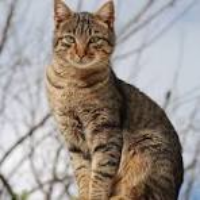

In [152]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread("1cat.jpg")

img_resized = cv2.resize(img, (200,200))

cv2_imshow(img_resized)